In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from PIL import Image
import matplotlib.pyplot as plt
import json

In [16]:
data_dir = "../Dataset/Train"
batch_size = 8
num_epochs = 30

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [17]:
normalize = transforms.Normalize(
    [0.485,0.456,0.406],
    [0.229,0.224,0.225]
)

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    normalize
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalize
])


In [18]:
full_dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)

class_names = full_dataset.classes
print("Classes:", class_names)

with open("classes.json", "w") as f:
    json.dump(class_names, f)

num_classes = len(class_names)


train_size = int(0.75 * len(full_dataset))
val_size = len(full_dataset) - train_size

torch.manual_seed(42)
indices = torch.randperm(len(full_dataset)).tolist()

train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_dataset = torch.utils.data.Subset(
    datasets.ImageFolder(root=data_dir, transform=train_transform),
    train_indices
)

val_dataset = torch.utils.data.Subset(
    datasets.ImageFolder(root=data_dir, transform=val_transform),
    val_indices
)

val_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)


Classes: ['Damaged', 'Good', 'Rusty']


In [19]:
model = models.mobilenet_v2(pretrained=True)


for param in model.features.parameters():
    param.requires_grad = False

model.classifier[1] = nn.Linear(model.last_channel, num_classes)

model = model.to(device)

from collections import Counter

counts = Counter(full_dataset.targets)
total = sum(counts.values())

weights = [total / counts[i] for i in range(len(counts))]
weights = torch.tensor(weights).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

In [25]:
# History lists (place before the training loop)
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_acc = 0.0

for epoch in range(num_epochs):

    model.train()

    total_loss = 0

    # ---------- NEW ----------
    train_correct = 0
    train_total = 0
    # -------------------------

    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        # ---------- NEW ----------
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        # -------------------------

    avg_loss = total_loss / len(train_loader)

    # ---------- NEW ----------
    train_acc = 100 * train_correct / train_total

    train_losses.append(avg_loss)
    train_accuracies.append(train_acc)
    # -------------------------

    # ================= VALIDATION =================

    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)

    accuracy = 100 * correct / total

    # ---------- NEW ----------
    val_losses.append(val_loss)
    val_accuracies.append(accuracy)
    # -------------------------

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {avg_loss:.4f} | Train Accuracy: {train_acc:.2f}%")
    print(f"Validation Loss: {val_loss:.4f} | Validation Accuracy: {accuracy:.2f}%")

    if accuracy > best_acc:

        best_acc = accuracy

        torch.save(model.state_dict(), "../Models/best_model.pth")

        print("Best model saved!")

    print()

Epoch [1/30]
Train Loss: 0.0806 | Train Accuracy: 96.30%
Validation Loss: 0.2764 | Validation Accuracy: 94.44%
Best model saved!

Epoch [2/30]
Train Loss: 0.1076 | Train Accuracy: 98.15%
Validation Loss: 0.2589 | Validation Accuracy: 91.67%

Epoch [3/30]
Train Loss: 0.0946 | Train Accuracy: 98.15%
Validation Loss: 0.2555 | Validation Accuracy: 94.44%

Epoch [4/30]
Train Loss: 0.0960 | Train Accuracy: 97.22%
Validation Loss: 0.2253 | Validation Accuracy: 94.44%

Epoch [5/30]
Train Loss: 0.0625 | Train Accuracy: 98.15%
Validation Loss: 0.2874 | Validation Accuracy: 94.44%

Epoch [6/30]
Train Loss: 0.0610 | Train Accuracy: 98.15%
Validation Loss: 0.2730 | Validation Accuracy: 91.67%

Epoch [7/30]
Train Loss: 0.1269 | Train Accuracy: 95.37%
Validation Loss: 0.2772 | Validation Accuracy: 91.67%

Epoch [8/30]
Train Loss: 0.0984 | Train Accuracy: 95.37%
Validation Loss: 0.3493 | Validation Accuracy: 94.44%

Epoch [9/30]
Train Loss: 0.0720 | Train Accuracy: 98.15%
Validation Loss: 0.3071 | Val

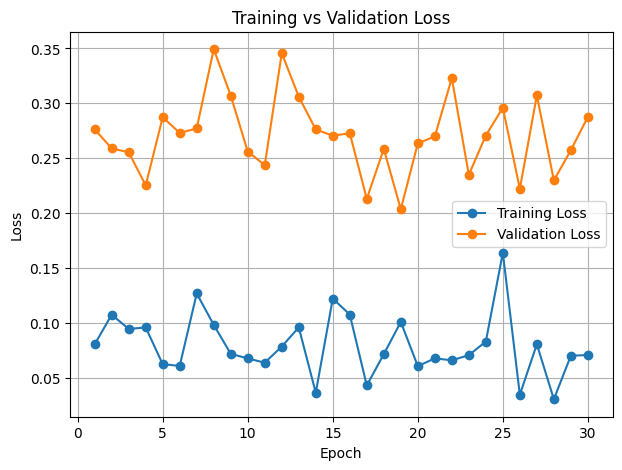

In [30]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(7,5))

plt.plot(epochs, train_losses, marker='o', label='Training Loss')
plt.plot(epochs, val_losses, marker='o', label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

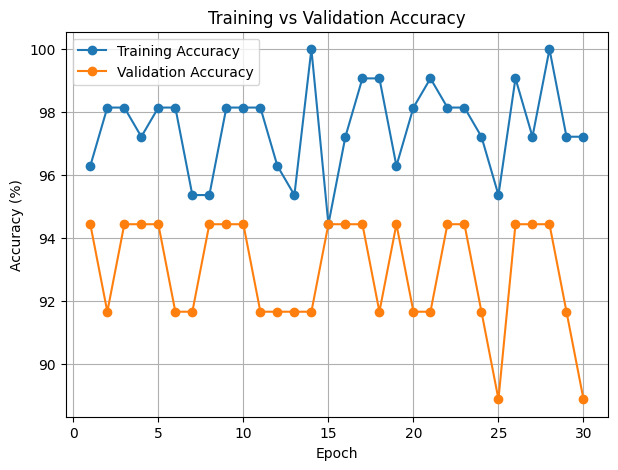

In [29]:
epochs = range(1, len(train_accuracies) + 1)

plt.figure(figsize=(7,5))

plt.plot(epochs, train_accuracies, marker='o', label='Training Accuracy')
plt.plot(epochs, val_accuracies, marker='o', label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()